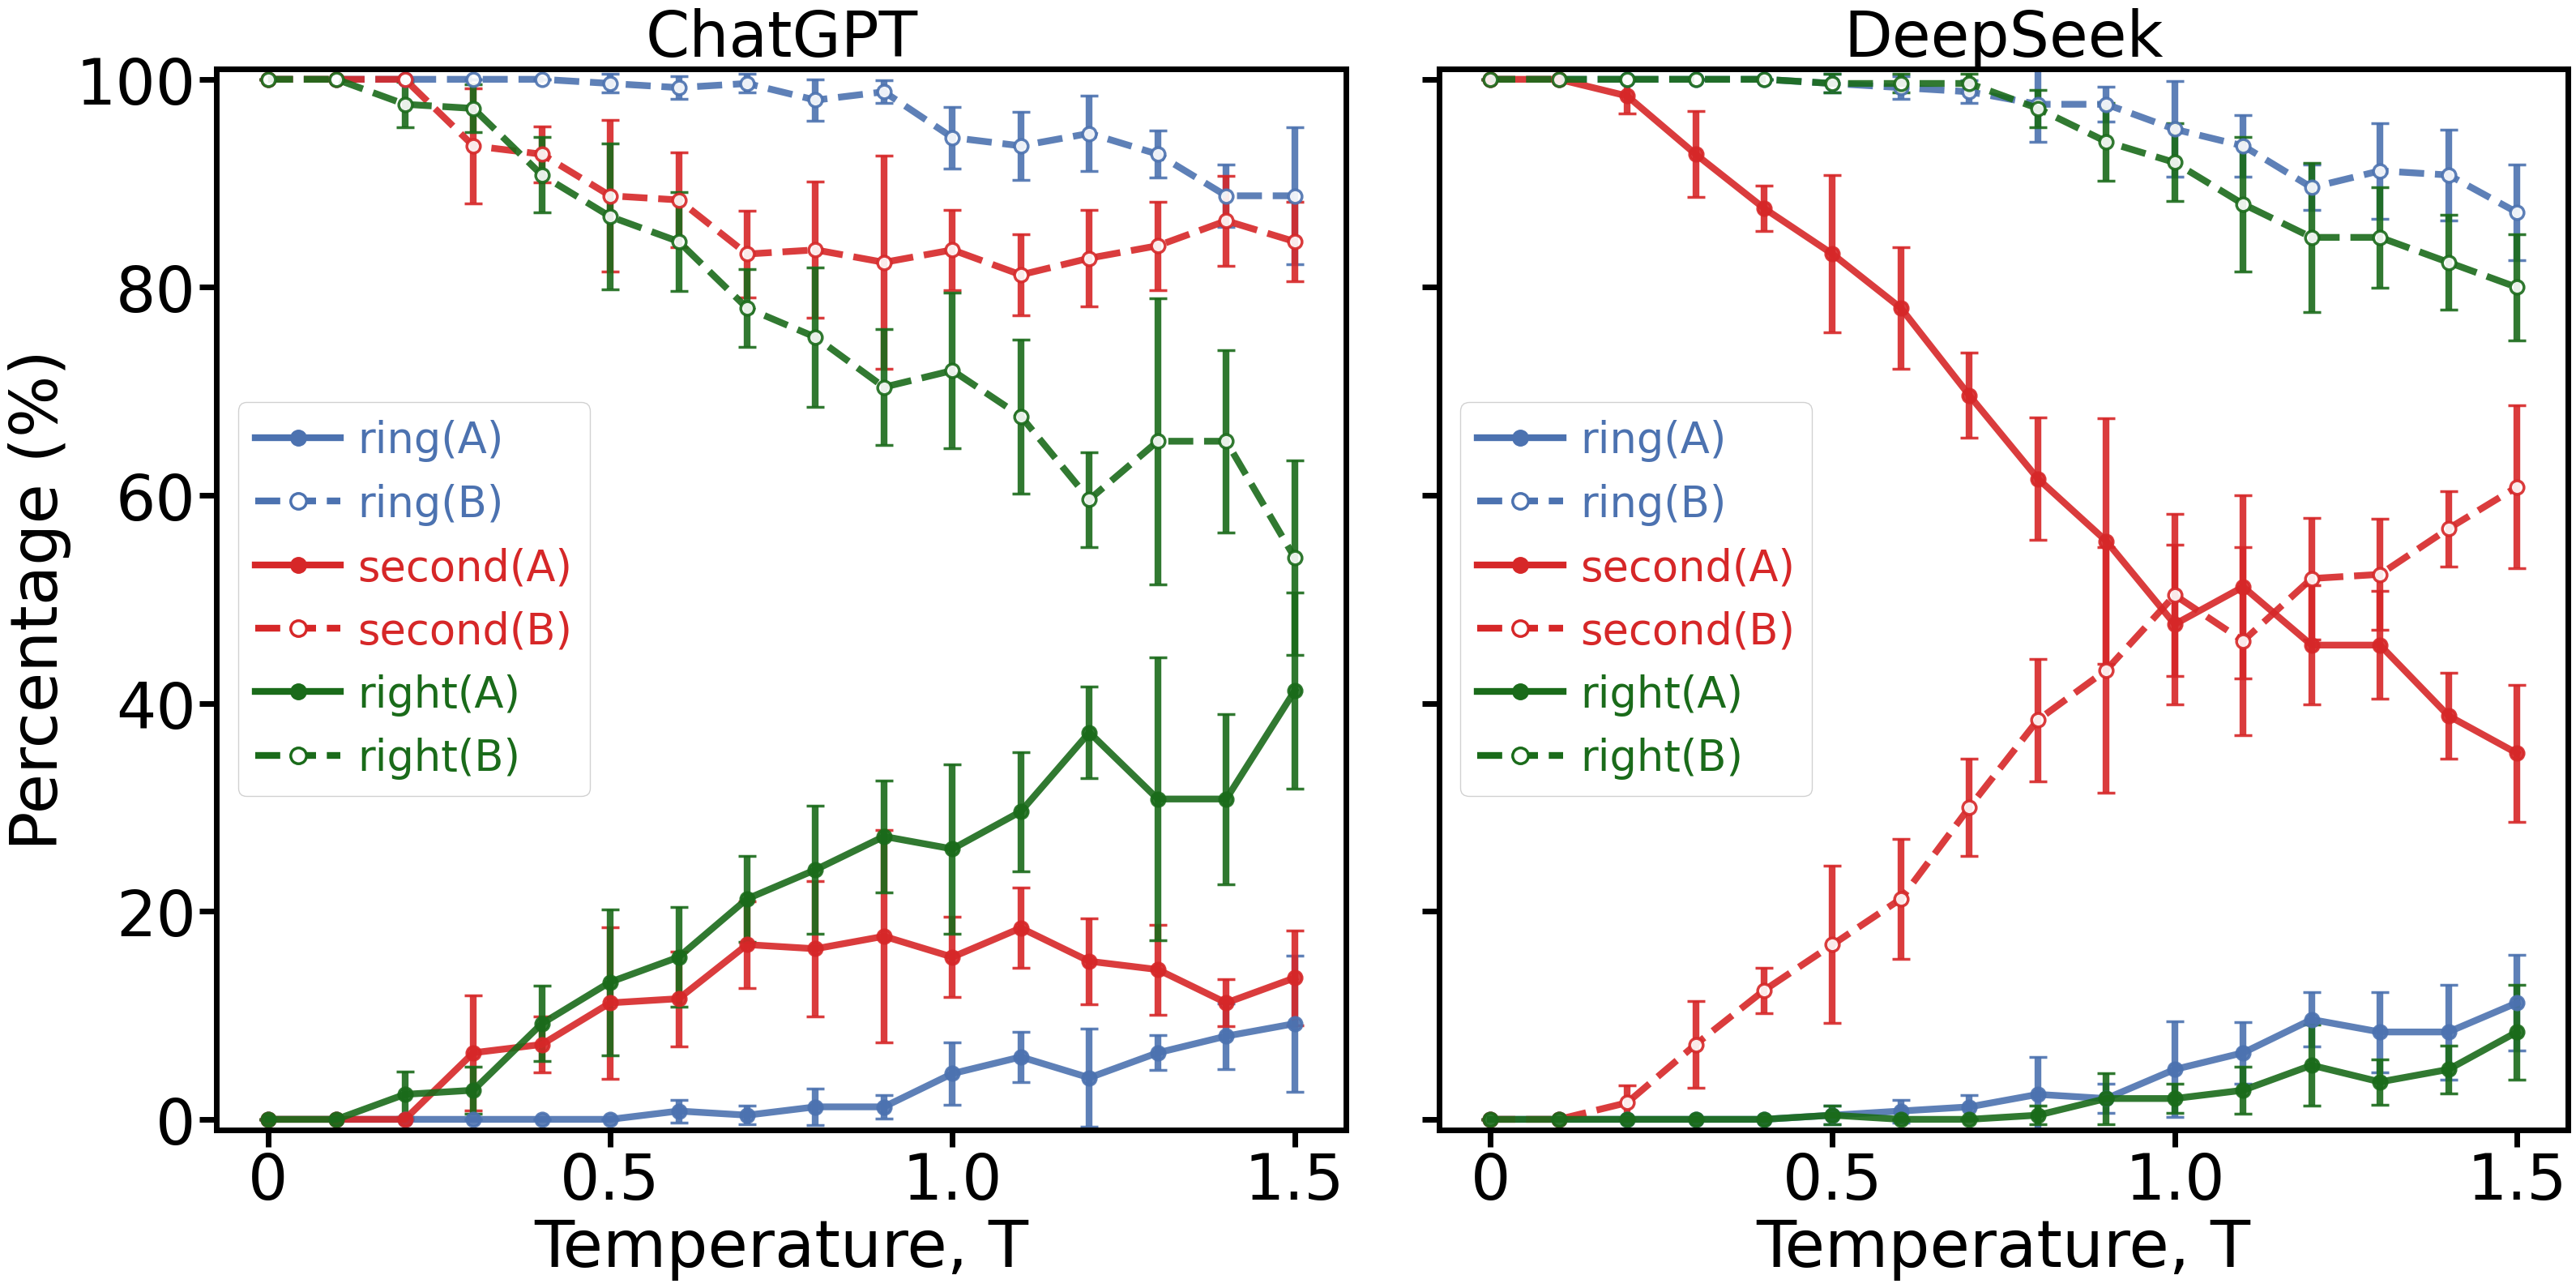

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.lines import Line2D

WORD_LIST = ["ring", "second", "right"]

TEMPS_PER_WORD = {
    "ring":   [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    "second": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    "right":  [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
}

MODEL_CONFIGS = [
    ("ChatGPT",  "result_chatgpt_corrected"),
    ("DeepSeek", "result_deepseek_corrected"),
]

WORD_COLORS = {
    "ring":   "#4C72B0",
    "second": "#D62728",
    "right":  "#1A6B1A",
}

SENSE_STYLES = {
    "A": {"linestyle": "-"},
    "B": {"linestyle": "--"},
}

CURVE_CONFIGS = [
    (["A"], "A"),
    (["B"], "B"),
]

def load_all_runs(base_dir: str, word: str, temps: list) -> pd.DataFrame:
    word_dir = os.path.join(base_dir, word)
    dfs = []
    for run_str in sorted(os.listdir(word_dir)):
        run_path = os.path.join(word_dir, run_str)
        if not (os.path.isdir(run_path) and run_str.isdigit()):
            continue
        for fname in sorted(os.listdir(run_path)):
            if not fname.startswith("T_") or not fname.endswith(".csv"):
                continue
            df_tmp = pd.read_csv(os.path.join(run_path, fname))
            df_tmp["run"] = int(run_str)
            dfs.append(df_tmp)
    df = pd.concat(dfs, ignore_index=True)
    return df[df["temp"].isin(temps)].copy()

all_stats = {}
for model_name, base_dir in MODEL_CONFIGS:
    all_stats[model_name] = {}
    for word in WORD_LIST:
        temps    = TEMPS_PER_WORD[word]
        df_all   = load_all_runs(base_dir, word, temps)
        df_valid = df_all[df_all["label"] != "?"].copy()

        all_stats[model_name][word] = {}
        for lbls, name in CURVE_CONFIGS:
            run_ratio = (
                df_valid.groupby(["run", "temp"])["label"]
                .apply(lambda x, l=lbls: x.isin(l).sum() / len(x) * 100)
                .reset_index(name="ratio")
            )
            stats = (
                run_ratio.groupby("temp")["ratio"]
                .agg(mean="mean", std="std", count="count")
                .reset_index()
            )
            stats["std"] = stats["std"].fillna(0)
            all_stats[model_name][word][name] = stats

fig, axes = plt.subplots(1, 2, figsize=(32, 16), sharey=True)

for col_idx, (model_name, _) in enumerate(MODEL_CONFIGS):
    ax = axes[col_idx]

    for word in WORD_LIST:
        color = WORD_COLORS[word]

        for lbls, sense in CURVE_CONFIGS:
            stats     = all_stats[model_name][word][sense]
            linestyle = SENSE_STYLES[sense]["linestyle"]
            mfc       = "white" if sense == "B" else color

            ax.errorbar(
                stats["temp"], stats["mean"],
                yerr=stats["std"],
                linestyle=linestyle,
                marker="o",
                markerfacecolor=mfc,       
                markeredgecolor=color,        
                markeredgewidth=2.5,          
                linewidth=6,
                markersize=12,
                capsize=8,
                capthick=5,
                color=color,
                ecolor=color,
                alpha=0.9,
                label=f"{word}({sense})",
            )

    ax.set_xticks([0.0, 0.5, 1.0, 1.5])
    ax.set_xticklabels(["0", "0.5", "1.0", "1.5"], rotation=0, fontsize=56)
    ax.set_ylim(-1, 101)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.tick_params(axis="both", which="major", length=15, width=5, labelsize=56)
    plt.setp(ax.spines.values(), linewidth=5)

    ax.set_title(model_name, fontsize=56)
    ax.set_xlabel("Temperature, T", fontsize=58)
    if col_idx == 0:
        ax.set_ylabel("Percentage (%)", fontsize=58)

    legend_elements = [
        Line2D([0], [0], color=WORD_COLORS["ring"],   lw=6, linestyle="-",
               marker="o", markersize=14,
               markerfacecolor=WORD_COLORS["ring"],   markeredgecolor=WORD_COLORS["ring"],
               label="ring(A)"),
        Line2D([0], [0], color=WORD_COLORS["ring"],   lw=6, linestyle="--",
               marker="o", markersize=14,
               markerfacecolor="white",               markeredgecolor=WORD_COLORS["ring"],
               markeredgewidth=2.5, label="ring(B)"),
        Line2D([0], [0], color=WORD_COLORS["second"], lw=6, linestyle="-",
               marker="o", markersize=14,
               markerfacecolor=WORD_COLORS["second"], markeredgecolor=WORD_COLORS["second"],
               label="second(A)"),
        Line2D([0], [0], color=WORD_COLORS["second"], lw=6, linestyle="--",
               marker="o", markersize=14,
               markerfacecolor="white",               markeredgecolor=WORD_COLORS["second"],
               markeredgewidth=2.5, label="second(B)"),
        Line2D([0], [0], color=WORD_COLORS["right"],  lw=6, linestyle="-",
               marker="o", markersize=14,
               markerfacecolor=WORD_COLORS["right"],  markeredgecolor=WORD_COLORS["right"],
               label="right(A)"),
        Line2D([0], [0], color=WORD_COLORS["right"],  lw=6, linestyle="--",
               marker="o", markersize=14,
               markerfacecolor="white",               markeredgecolor=WORD_COLORS["right"],
               markeredgewidth=2.5, label="right(B)"),
    ]

    leg = ax.legend(handles=legend_elements, fontsize=38, loc="center left",
                    framealpha=0.9, handletextpad=0.4)

    word_order = ["ring", "ring", "second", "second", "right", "right"]
    for text, word in zip(leg.get_texts(), word_order):
        text.set_color(WORD_COLORS[word])

plt.tight_layout(w_pad=6)
plt.show()


========== ChatGPT ==========
  [ChatGPT][ring]  ΔU = +3.1794  |  ΔS = -0.2575  |  R² = 0.8406
  [ChatGPT][second]  ΔU = +0.3886  |  ΔS = -1.3491  |  R² = 0.6812
  [ChatGPT][right]  ΔU = +0.8318  |  ΔS = -0.0937  |  R² = 0.9254

========== DeepSeek ==========
  [DeepSeek][ring]  ΔU = +2.6950  |  ΔS = -0.3438  |  R² = 0.9594
  [DeepSeek][second]  ΔU = -1.0605  |  ΔS = -0.9023  |  R² = 0.9667
  [DeepSeek][right]  ΔU = +2.4536  |  ΔS = -1.1645  |  R² = 0.7692


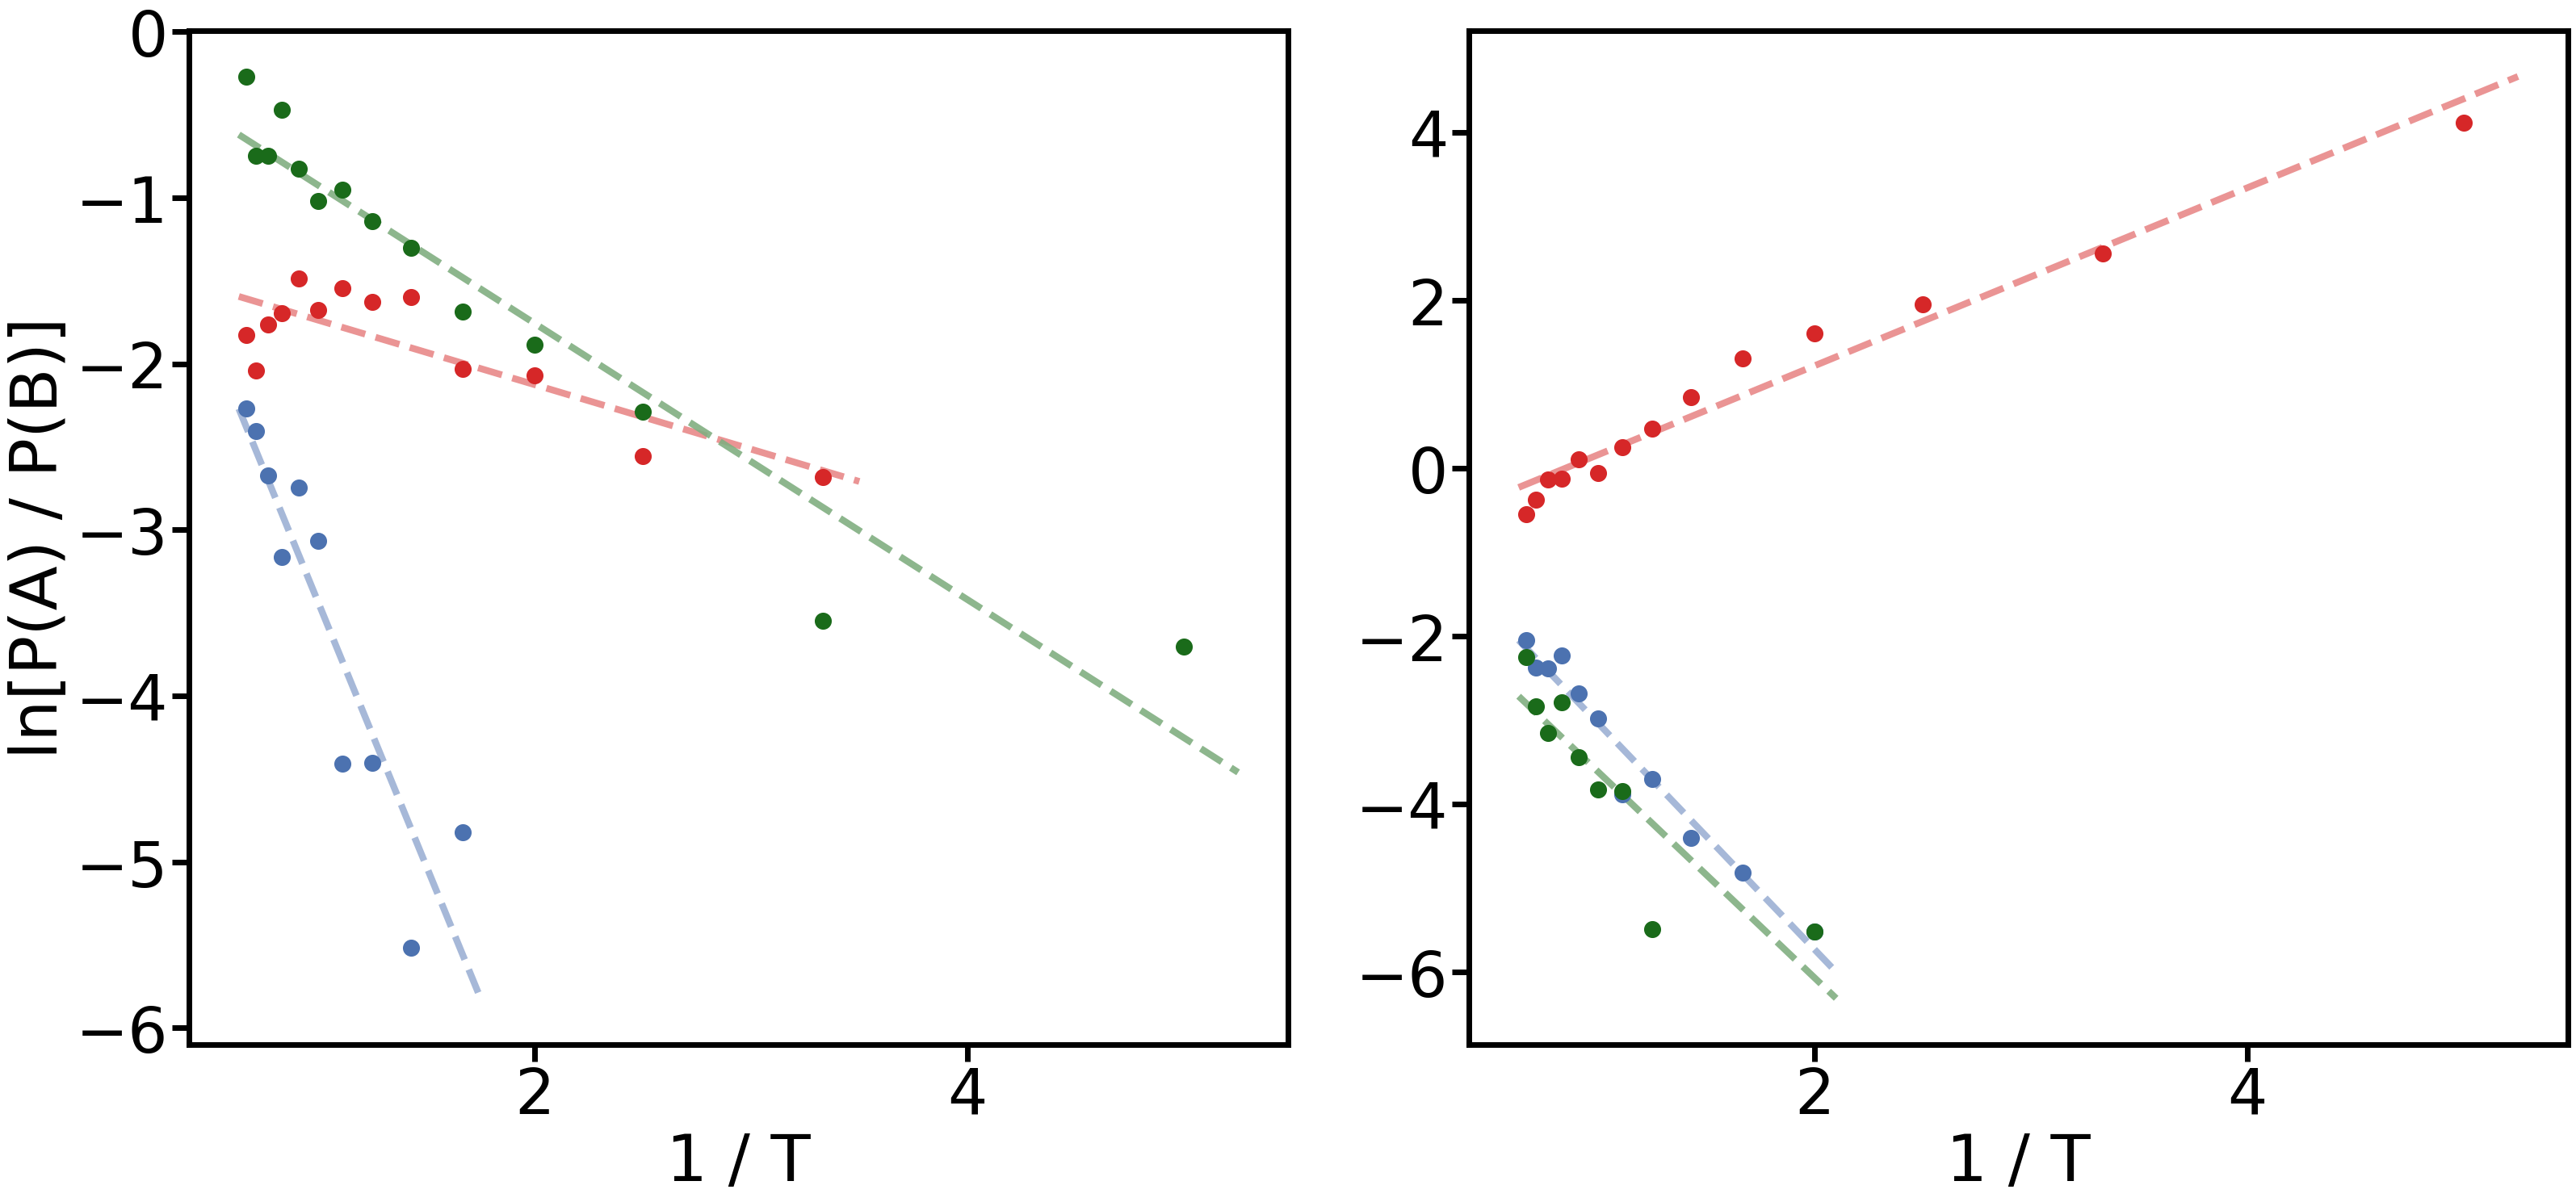

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
import os
import pandas as pd

FIT_WORDS = ["ring", "second", "right"]

TEMPS_PER_WORD = {
    "ring":   [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    "second": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    "right":  [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
               1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
}

MODEL_CONFIGS = [
    ("ChatGPT",  "result_chatgpt_corrected"),
    ("DeepSeek", "result_deepseek_corrected"),
]

WORD_COLORS = {
    "ring":   "#4C72B0",
    "second": "#D62728", 
    "right":  "#1A6B1A", 
}

def lighten_color(color, amount=0.45):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - ch) * (1 - amount) for ch in c)


def load_all_runs(base_dir: str, word: str, temps: list) -> pd.DataFrame:
    word_dir = os.path.join(base_dir, word)
    dfs = []
    for run_str in sorted(os.listdir(word_dir)):
        run_path = os.path.join(word_dir, run_str)
        if not (os.path.isdir(run_path) and run_str.isdigit()):
            continue
        for fname in sorted(os.listdir(run_path)):
            if not fname.startswith("T_") or not fname.endswith(".csv"):
                continue
            df_tmp = pd.read_csv(os.path.join(run_path, fname))
            df_tmp["run"] = int(run_str)
            dfs.append(df_tmp)
    df = pd.concat(dfs, ignore_index=True)
    return df[df["temp"].isin(temps)].copy()

def build_pA_pB(base_dir, word, temps):
    df_all   = load_all_runs(base_dir, word, temps)
    df_valid = df_all[df_all["label"] != "?"].copy()

    grouped = df_valid.groupby(["run", "temp"])["label"]
    run_ratio = pd.DataFrame({
        "pA": grouped.apply(lambda x: (x == "A").sum() / len(x)),
        "pB": grouped.apply(lambda x: (x == "B").sum() / len(x)),
    }).reset_index()

    return run_ratio.groupby("temp")[["pA", "pB"]].mean().reset_index()


def vant_hoff_fit(temperatures, p_A, p_B, word="", model_name=""):
    eps   = 1e-10
    temps = np.array(temperatures)
    p_A   = np.array(p_A)
    p_B   = np.array(p_B)

    valid = (p_A > eps) & (p_B > eps)
    if valid.sum() < 3:
        print(f"  [{model_name}][{word}] 有效点不足 ({valid.sum()})，跳过")
        return None

    T_v      = temps[valid]
    inv_T    = 1.0 / T_v
    ln_ratio = np.log(p_A[valid] / p_B[valid])

    reg = LinearRegression().fit(inv_T.reshape(-1, 1), ln_ratio)
    slope, intercept = reg.coef_[0], reg.intercept_

    y_pred = reg.predict(inv_T.reshape(-1, 1))
    ss_res = np.sum((ln_ratio - y_pred) ** 2)
    ss_tot = np.sum((ln_ratio - ln_ratio.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0

    print(f"  [{model_name}][{word}]  ΔU = {-slope:+.4f}  "
          f"|  ΔS = {intercept:+.4f}  |  R² = {r2:.4f}")

    return {
        "word": word, "delta_U": -slope, "delta_S": intercept,
        "r2": r2, "T_valid": T_v, "inv_T": inv_T,
        "ln_ratio": ln_ratio, "slope": slope, "intercept": intercept,
    }

all_results = {}
for model_name, base_dir in MODEL_CONFIGS:
    all_results[model_name] = {}
    print(f"\n{'='*10} {model_name} {'='*10}")
    for word in FIT_WORDS:
        word_dir = os.path.join(base_dir, word)
        if not os.path.exists(word_dir):
            print(f"  跳过 [{word}]：目录不存在")
            continue
        temps = TEMPS_PER_WORD[word]
        agg   = build_pA_pB(base_dir, word, temps=temps)
        agg   = agg[agg["temp"] > 0].reset_index(drop=True)
        all_results[model_name][word] = vant_hoff_fit(
            agg["temp"].values, agg["pA"].values, agg["pB"].values,
            word=word, model_name=model_name,
        )

fig, axes = plt.subplots(1, 2, figsize=(32, 15), sharey=False)
ylabel_str = 'ln[P(A) / P(B)]'

for ax, (model_name, _) in zip(axes, MODEL_CONFIGS):

    for word in FIT_WORDS:
        result = all_results[model_name].get(word)
        if result is None:
            continue

        color      = WORD_COLORS[word]
        color_line = lighten_color(color, 0.45)

        ax.scatter(
            result["inv_T"], result["ln_ratio"],
            s=200, color=color, zorder=5, alpha=1,
        )

        x_fit = np.linspace(
            result["inv_T"].min() * 0.95,
            result["inv_T"].max() * 1.05,
            300,
        )
        y_fit = result["slope"] * x_fit + result["intercept"]
        ax.plot(
            x_fit, y_fit,
            color=color_line,
            linewidth=6, linestyle="--", alpha=0.9,
            label=f'"{word}"',
        )

    ax.set_xlabel("1 / T", fontsize=58)
    ax.tick_params(axis="both", which="major", length=15, width=5, labelsize=56)
    plt.setp(ax.spines.values(), linewidth=5)

axes[0].set_ylabel(ylabel_str, fontsize=58)

plt.tight_layout(w_pad=6)
plt.show()